LIMPIEZA DE DATOS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ruta = 'https://raw.githubusercontent.com/marinlopabi/Temas_Selectos_PQ_26-I/refs/heads/main/ARCHIVOS/metro_ingresos.csv'
df = pd.read_csv (ruta,parse_dates = True, index_col= 0, sep=',')
df.head()

,tipo_ingreso,linea,ingreso
fecha,,,
2022-01-01,Boletos,Línea 1,324825.0
2022-01-01,NaN,NaN,NaN
2022-01-01,NaN,NaN,180225.0
2022-01-01,Boletos,Línea 4,NaN
2022-01-01,NaN,Línea 5,134725.0


In [5]:
df_cop = df.copy() # copia del df original

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17532 entries, 2022-01-01 to 2022-12-31
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   tipo_ingreso  17493 non-null  object 
 1   linea         17430 non-null  object 
 2   ingreso       17359 non-null  float64
dtypes: float64(1), object(2)
memory usage: 547.9+ KB


In [8]:
df.shape

(17532, 3)

In [9]:
df.columns

Index(['tipo_ingreso', 'linea', 'ingreso'], dtype='object')

In [10]:
df.sample(5)

,tipo_ingreso,linea,ingreso
fecha,,,
2022-08-12,Boletos,Línea 5,300775.0
2022-12-21,Recargas,Línea 12,0.0
2022-02-02,Recargas,Línea 7,678096.7
2022-06-26,QR/Validación,Línea 8,0.0
2022-12-14,QR/Validador,Línea 3,0.0


In [11]:
df.sample(15)

,tipo_ingreso,linea,ingreso
fecha,,,
2022-07-30,Tarjetas,Línea B,6750.0000
2022-02-14,Boletos,Línea 12,0.0000
2022-09-16,Tarjetas,Línea 9,4080.0000
2022-04-05,Recargas,Línea B,922492.1382
2022-12-16,Recargas,Línea 7,944312.8000
2022-05-31,QR/Validación,Línea B,0.0000
2022-05-15,Boletos,Línea B,463225.0000
2022-05-01,Tarjetas,Línea 8,1785.0000
2022-12-24,Tarjetas,Línea 9,3090.0000


In [12]:
df.describe(include='all') #describe es para datos estadisticos

,tipo_ingreso,linea,ingreso
count,17493,17430,1.735900e+04
unique,5,12,NaN
top,Boletos,Línea 1,NaN
freq,4375,1454,NaN
mean,NaN,NaN,2.771655e+05
std,NaN,NaN,4.117393e+05
min,NaN,NaN,0.000000e+00
25%,NaN,NaN,0.000000e+00
50%,NaN,NaN,8.805000e+03
75%,NaN,NaN,4.468910e+05


Si hay valores faltantes, pandas lo muestra como NaN

In [13]:
df.isna().sum()

,0
tipo_ingreso,39
linea,102
ingreso,173


podemos eliminar los datos faltantes uuusando .dropna

In [15]:
df.dropna() #eliminar filas con valores faltantes

,tipo_ingreso,linea,ingreso
fecha,,,
2022-01-01,Boletos,Línea 1,324825.0
2022-01-01,Boletos,Línea A,163450.0
2022-01-01,Recargas,Línea 1,439332.5
2022-01-01,Recargas,Línea 2,369354.8
2022-01-01,Recargas,Línea 3,347269.8
...,...,...,...
2022-12-31,QR/Validador,Línea 1,0.0
2022-12-31,QR/Validador,Línea 2,0.0
2022-12-31,QR/Validador,Línea 4,0.0


In [17]:
df.shape

(17532, 3)

In [18]:
df.dropna().shape

(17240, 3)

eliminar filas completamente vacias

In [19]:
df.dropna(how='all')

,tipo_ingreso,linea,ingreso
fecha,,,
2022-01-01,Boletos,Línea 1,324825.0
2022-01-01,NaN,NaN,180225.0
2022-01-01,Boletos,Línea 4,NaN
2022-01-01,NaN,Línea 5,134725.0
2022-01-01,Boletos,NaN,NaN
...,...,...,...
2022-12-31,QR/Validador,NaN,NaN
2022-12-31,QR/Validador,Línea 8,NaN
2022-12-31,NaN,Línea 9,7590.0


el argumento thresh permite conservar unicamente aquellas filas que tengan un número minimo de valores no nulos

In [21]:
df.dropna(thresh=2) #mantener filas con un minimo de datos, en este caso 2

,tipo_ingreso,linea,ingreso
fecha,,,
2022-01-01,Boletos,Línea 1,324825.0
2022-01-01,Boletos,Línea 4,NaN
2022-01-01,NaN,Línea 5,134725.0
2022-01-01,Boletos,NaN,88100.0
2022-01-01,Boletos,Línea 8,NaN
...,...,...,...
2022-12-31,QR/Validador,Línea 6,NaN
2022-12-31,QR/Validador,Línea 8,NaN
2022-12-31,NaN,Línea 9,7590.0


rellenar valores faltantes

In [22]:
df.fillna(0) #rellenar con un valor fijo

,tipo_ingreso,linea,ingreso
fecha,,,
2022-01-01,Boletos,Línea 1,324825.0
2022-01-01,0,0,0.0
2022-01-01,0,0,180225.0
2022-01-01,Boletos,Línea 4,0.0
2022-01-01,0,Línea 5,134725.0
...,...,...,...
2022-12-31,QR/Validador,Línea 8,0.0
2022-12-31,0,Línea 9,7590.0
2022-12-31,QR/Validador,0,0.0


relleno especifico por columna

In [24]:
df.fillna({
    'tipo_ingreso':'otro',
    'linea':'desconocida',
    'ingreso': 0
})

,tipo_ingreso,linea,ingreso
fecha,,,
2022-01-01,Boletos,Línea 1,324825.0
2022-01-01,otro,desconocida,0.0
2022-01-01,otro,desconocida,180225.0
2022-01-01,Boletos,Línea 4,0.0
2022-01-01,otro,Línea 5,134725.0
...,...,...,...
2022-12-31,QR/Validador,Línea 8,0.0
2022-12-31,otro,Línea 9,7590.0
2022-12-31,QR/Validador,desconocida,0.0


propagacion hacia adelante, usando el metodo ffill(), el cual copia hacia adelante el ultimo valor nulo observado

In [25]:
df.ffill()

,tipo_ingreso,linea,ingreso
fecha,,,
2022-01-01,Boletos,Línea 1,324825.0
2022-01-01,Boletos,Línea 1,324825.0
2022-01-01,Boletos,Línea 1,180225.0
2022-01-01,Boletos,Línea 4,180225.0
2022-01-01,Boletos,Línea 5,134725.0
...,...,...,...
2022-12-31,QR/Validador,Línea 8,0.0
2022-12-31,QR/Validador,Línea 9,7590.0
2022-12-31,QR/Validador,Línea 9,0.0


In [26]:
df['ingreso'].fillna(df['ingreso'].median())

,ingreso
fecha,
2022-01-01,324825.0
2022-01-01,8805.0
2022-01-01,180225.0
2022-01-01,8805.0
2022-01-01,134725.0
...,...
2022-12-31,8805.0
2022-12-31,7590.0
2022-12-31,0.0


In [27]:
df['ingreso'].fillna(df['ingreso'].mean())

,ingreso
fecha,
2022-01-01,324825.000000
2022-01-01,277165.486327
2022-01-01,180225.000000
2022-01-01,277165.486327
2022-01-01,134725.000000
...,...
2022-12-31,277165.486327
2022-12-31,7590.000000
2022-12-31,0.000000


In [28]:
df.duplicated().sum() #duplicados

np.int64(6702)

In [29]:
df[df.duplicated()]

,tipo_ingreso,linea,ingreso
fecha,,,
2022-01-01,Boletos,NaN,NaN
2022-01-01,NaN,NaN,NaN
2022-01-02,Tarjetas,Línea 12,0.0
2022-01-02,QR/Validación,Línea 1,0.0
2022-01-02,NaN,NaN,NaN
...,...,...,...
2022-12-31,NaN,NaN,0.0
2022-12-31,QR/Validador,Línea 4,0.0
2022-12-31,QR/Validador,Línea 5,0.0


In [30]:
df_sin_duplicados = df.drop_duplicates()
df_sin_duplicados.shape

(10830, 3)

In [32]:
df

,tipo_ingreso,linea,ingreso
fecha,,,
2022-01-01,Boletos,Línea 1,324825.0
2022-01-01,NaN,NaN,NaN
2022-01-01,NaN,NaN,180225.0
2022-01-01,Boletos,Línea 4,NaN
2022-01-01,NaN,Línea 5,134725.0
...,...,...,...
2022-12-31,QR/Validador,Línea 8,NaN
2022-12-31,NaN,Línea 9,7590.0
2022-12-31,QR/Validador,NaN,0.0


Estandarización de texto
En variabes categoricas es comun encontrar problemas como
* espacio al inicio o al final
* mayusculas y minusculas mezcladas
* etiquetas escritas de manera inconsistente

In [34]:
df['linea'].unique()

array(['Línea 1', nan, 'Línea 4', 'Línea 5', 'Línea 8', 'Línea 9',
       'Línea A', 'Línea 12', 'Línea 2', 'Línea 3', 'Línea 6', 'Línea 7',
       'Línea B'], dtype=object)

In [35]:
df['linea'] = df['linea'].astype(str).str.strip()
df['tipo_ingreso'] = df['tipo_ingreso'].astype(str).str.strip().str.lower()

In [37]:
df['tipo_ingreso'].unique()

array(['boletos', 'nan', 'recargas', 'tarjetas', 'qr/validación',
       'qr/validador'], dtype=object)

correccion de tipo de datos

In [57]:
df.index = pd.to_datetime(df.index, errors='coerce') #convierte en NaT cualquier valor no interpretados

In [62]:
ruta = 'https://raw.githubusercontent.com/marinlopabi/Temas_Selectos_PQ_26-I/refs/heads/main/ARCHIVOS/ingresosstc_2023_07.csv'
df1 = pd.read_csv(ruta, sep=',')
df1.head()

,fecha,tipo_ingreso,linea,ingreso
0,2012-01-01,Boletos,Línea 1,648825.0
1,2012-01-01,Boletos,Línea 2,657120.0
2,2012-01-01,Boletos,Línea 3,466803.0
3,2012-01-01,Boletos,Línea 4,60120.0
4,2012-01-01,Boletos,Línea 5,242280.0


In [63]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159948 entries, 0 to 159947
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   fecha         159948 non-null  object 
 1   tipo_ingreso  159948 non-null  object 
 2   linea         159948 non-null  object 
 3   ingreso       158881 non-null  float64
dtypes: float64(1), object(3)
memory usage: 4.9+ MB


In [64]:
df1['fecha'] = pd.to_datetime(df1['fecha'], errors='coerce')

In [65]:
df1['fecha'].isna().sum()

np.int64(0)

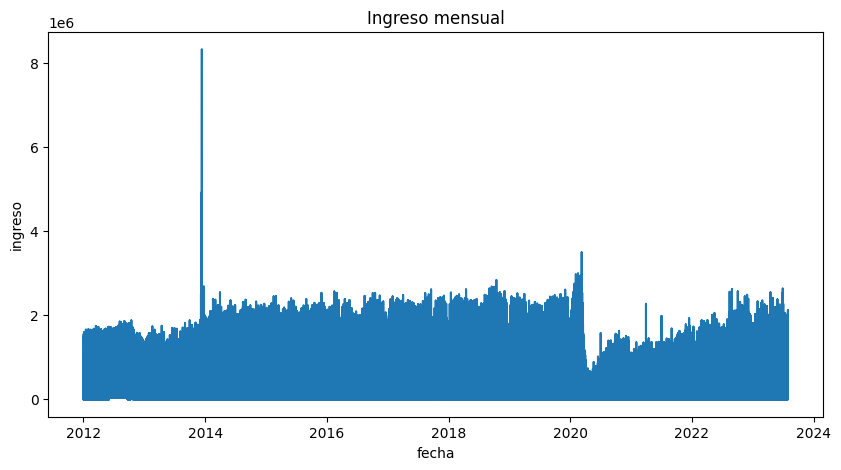

In [66]:
plt.figure(figsize=(10,5))
plt.plot(df1['fecha'],df1['ingreso'])
plt.xlabel('fecha')
plt.ylabel('ingreso')
plt.title('Ingreso mensual')
plt.show()

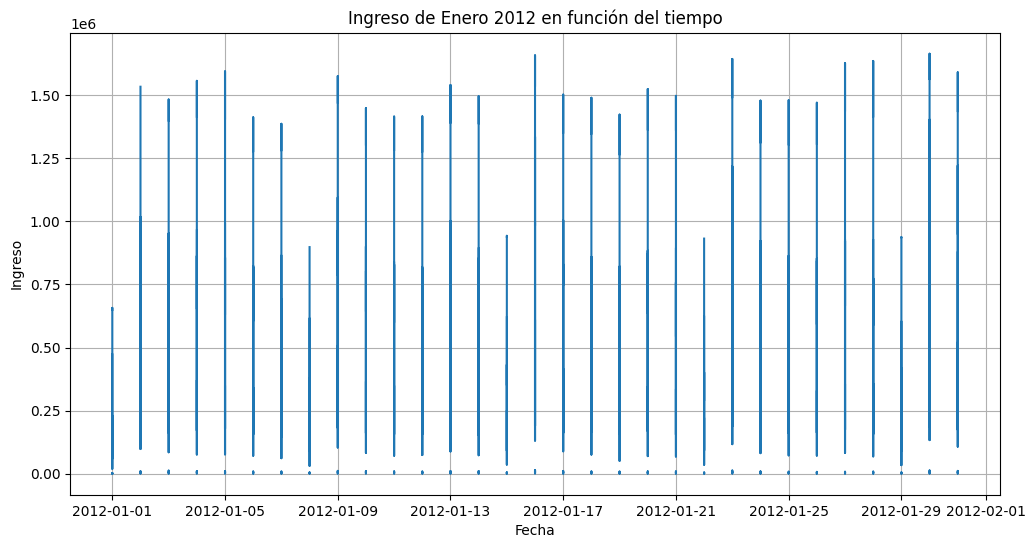

In [69]:
df1_enero_2012 = df1[(df1['fecha'].dt.month == 1) & (df1['fecha'].dt.year == 2012)]
plt.figure(figsize=(12,6))
plt.plot(df1_enero_2012['fecha'], df1_enero_2012['ingreso'])
plt.xlabel('Fecha')
plt.ylabel('Ingreso')
plt.title('Ingreso de Enero 2012 en función del tiempo')
plt.grid(True)
plt.show()

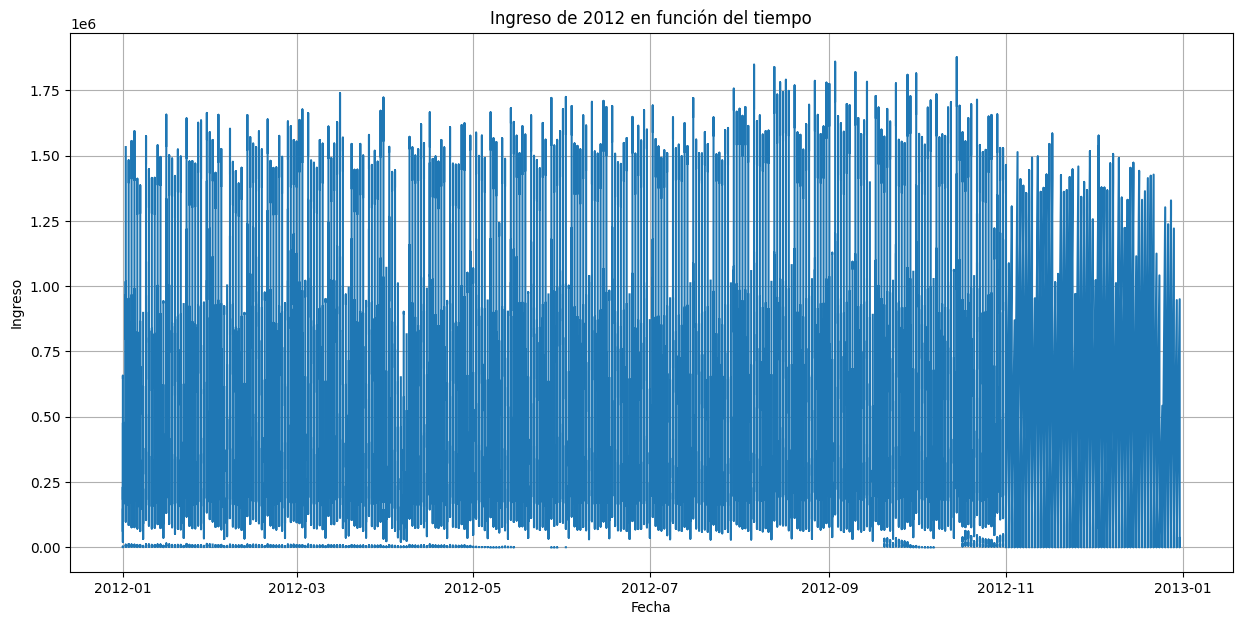

In [70]:
df1_2012 = df1[df1['fecha'].dt.year == 2012]

plt.figure(figsize=(15, 7))
plt.plot(df1_2012['fecha'], df1_2012['ingreso'])
plt.xlabel('Fecha')
plt.ylabel('Ingreso')
plt.title('Ingreso de 2012 en función del tiempo')
plt.grid(True)
plt.show()

In [ ]:
f_enero_2012 = df1.loc['2012-01']
df_enero_2012_linea1 = df_enero_2012[df_enero_2012['linea'] == 'Línea 1']
df_ingresos_diarios_linea1 = df_enero_2012_linea1.groupby(df_enero_2012_linea1.index)['ingreso'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='fecha', y='ingreso', data=df_ingresos_diarios_linea1)
plt.title('Ingresos Diarios de la Línea 1 en Enero de 2012')
plt.xlabel('Fecha')
plt.ylabel('Ingreso')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()